# $L_2$ Regularization with ParmEst

Parameter estimation problems can be challenging when the available data are
limited, noisy, or weakly informative for some parameters. In these cases, the
least squares or maximum likelihood objective may have broad valleys, multiple
local optima, or parameter estimates that are physically unreasonable.

One way to incorporate additional information is through **regularization**.
Regularization augments the parameter estimation objective with an additional
term that penalizes deviations from prior parameter values.

Let $\boldsymbol{\theta}_0$ denote a vector of prior or nominal parameter values,
and let $\boldsymbol{F}_{\text{prior}}$ denote a prior Fisher information matrix
(FIM). The prior FIM represents the amount of information available about the
parameters before fitting the current data. This information may come from
previous experiments, previous parameter estimation studies, literature values,
or expert knowledge.

The regularized parameter estimation problem can be written as

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
   +
   R(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})
$$

where $g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})$ is the objective
function from the current parameter estimation problem and
$R(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})$
is the regularization term.

---

## Maximum likelihood estimation and regularization

The current `ParmEst` parameter estimation workflow can be interpreted as a
maximum likelihood estimation (MLE) problem when the objective function is
derived from an assumed measurement error distribution.

For example, when Gaussian independent measurement errors are assumed, the
weighted sum of squared errors objective corresponds to the negative
log-likelihood of the observed data, up to additive constants. In this case,
solving

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
$$

is equivalent to finding the maximum likelihood estimate:

$$
   \hat{\boldsymbol{\theta}}_{\text{MLE}}
   =
   \arg\max_{\boldsymbol{\theta}}
   p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
$$

or, equivalently,

$$
   \hat{\boldsymbol{\theta}}_{\text{MLE}}
   =
   \arg\min_{\boldsymbol{\theta}}
   -
   \log
   p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
$$

Regularization modifies this objective by adding prior information about the
parameters. The regularized problem is

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
   +
   R(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})
$$

This can be viewed as a bridge between MLE and Bayesian parameter estimation.

### Import the necessary packages

In [1]:
import sys
import numpy as np
import pandas as pd

# If running on Google Colab, install Pyomo and Ipopt via IDAES
on_colab = "google.colab" in sys.modules
if on_colab:
    !wget "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/notebooks/tclab_pyomo.py"

# import TCLab model, simulation, and data analysis functions
from tclab_pyomo import (
    TC_Lab_data,
    TC_Lab_experiment,
)

# set default number of states in the TCLab model
number_tclab_states = 2

### Load experimental data

In [2]:
# load experimental data
if on_colab:
    file = "https://raw.githubusercontent.com/dowlinglab/pyomo-doe/main/data/tclab_sine_test_5min_period.csv"
else:
    file = '../data/tclab_sine_test_5min_period.csv'
df = pd.read_csv(file)

# store in custom data class 
tc_data = TC_Lab_data(
    name="Sine Wave Test for Heater 1",
    time=df['Time'].values,
    T1=df['T1'].values,
    u1=df['Q1'].values,
    P1=200,
    TS1_data=None,
    T2=df['T2'].values,
    u2=df['Q2'].values,
    P2=200,
    TS2_data=None,
    Tamb=df['T1'].values[0],
)

# set default number of states in the TCLab model
number_tclab_states = 2

### Interpretation of the prior FIM

The prior FIM provides a way to encode prior information in a form that is
consistent with the local curvature of a parameter estimation objective.

A larger value in $\boldsymbol{F}_{\text{prior}}$ indicates that the prior
information strongly constrains a parameter or parameter combination. A smaller
value indicates weaker prior information. If the prior FIM contains off-diagonal
terms, then the regularization accounts for correlations between parameter
directions.

For $L_2$ regularization, the full prior FIM can be used directly:

$$
   R_{2}
   =
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

### Physically motivated prior information

For regularization, we define a weakly informative prior using physical intuition,
literature values, and expert knowledge. The purpose of this prior is not to fix
the parameter estimates, but to guide the optimization toward physically
reasonable values when the data are not strongly informative.

The nominal physical parameter values are

$$
U_a = 0.030 \; \text{W/K}, \qquad
U_b = 0.018 \; \text{W/K},
$$

$$
C_{p,H} = 7.5 \; \text{J/K}, \qquad
C_{p,S} = 0.22 \; \text{J/K}.
$$

Here, $U_a$ represents heat loss from the heater to the surroundings, $U_b$
represents heater-to-sensor coupling, $C_{p,H}$ is the heater thermal mass, and
$C_{p,S}$ is the sensor thermal mass. These values reflect the expectation that
the heater has a much larger effective heat capacity than the sensor, while both
thermal conductance parameters are small but nonzero.

Because the estimator uses inverse heat capacities, the prior is transformed to

$$
\boldsymbol{\theta}_0 =
\left[
U_a,\;
U_b,\;
\frac{1}{C_{p,H}},\;
\frac{1}{C_{p,S}}
\right]
\approx
\left[
0.030,\;
0.018,\;
0.133,\;
4.545
\right].
$$

To represent uncertainty in this prior, we specify a diagonal covariance matrix
in the estimator parameterization:

$$
\boldsymbol{\Sigma}_{\text{prior}}
=
\text{diag}\left(0.02,\;0.01,\;0.05,\;0.05\right).
$$

The diagonal form assumes no prior correlations, and the relatively large
variances make the prior weakly informative. The prior Fisher information matrix
is then computed as

$$
\boldsymbol{F}_{\text{prior}}
=
w_{\text{prior}}
\boldsymbol{\Sigma}_{\text{prior}}^{-1},
\qquad
w_{\text{prior}} = 0.05.
$$

This scaled prior FIM is used in the regularization term to discourage
physically unrealistic parameter values while still allowing the experimental
data to dominate the estimate.

In [3]:
 # Regularization using physically informed prior

# ---- Physically intuitive guesses (Cp-space) ----
theta_phys = pd.Series({
    "Ua": 0.030,   # W/K, ambient loss from heater node
    "Ub": 0.018,   # W/K, heater-to-sensor coupling
    "CpH": 7.5,    # J/K, heater thermal mass
    "CpS": 0.22,   # J/K, sensor thermal mass
})


# Transform to estimator parameterization [Ua, Ub, inv_CpH, inv_CpS]
theta0_phys = pd.Series({
    "Ua": theta_phys["Ua"],
    "Ub": theta_phys["Ub"],
    "inv_CpH": 1.0 / theta_phys["CpH"],
    "inv_CpS": 1.0 / theta_phys["CpS"],
})

# Define diagonal covariance matrix
cov_x = pd.DataFrame(
    np.diag([0.02, 0.01, 0.05, 0.05]),
    index=["Ua","Ub","inv_CpH","inv_CpS"],
    columns=["Ua","Ub","inv_CpH","inv_CpS"],
)

# Invert to get the physically informed prior_FIM
prior_FIM_phys = pd.DataFrame(
    np.linalg.inv(cov_x.values),
    index=cov_x.index,
    columns=cov_x.columns,
)

# Optional scaling factor to tune regularization strength
prior_weight = 2
prior_FIM_phys = prior_weight * prior_FIM_phys


print("theta0_phys:", theta0_phys)
print("prior_FIM_phys:\n", prior_FIM_phys)


theta0_phys: Ua         0.030000
Ub         0.018000
inv_CpH    0.133333
inv_CpS    4.545455
dtype: float64
prior_FIM_phys:
             Ua     Ub  inv_CpH  inv_CpS
Ua       100.0    0.0      0.0      0.0
Ub         0.0  200.0      0.0      0.0
inv_CpH    0.0    0.0     40.0      0.0
inv_CpS    0.0    0.0      0.0     40.0


## Adding regularization to objective in ParmEst

In $L_2$ regularization, the penalty is quadratic in the difference between the
estimated parameters and the prior parameter values.

Using a prior FIM, the $L_2$ regularization term can be written as

$$
   R_{2}(\boldsymbol{\theta}; \boldsymbol{\theta}_0, \boldsymbol{F}_{\text{prior}})
   =
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

so that the regularized parameter estimation problem becomes

$$
   \min_{\boldsymbol{\theta}} \;
   g(\boldsymbol{x}, \boldsymbol{y}; \boldsymbol{\theta})
   +
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

This term penalizes parameter values that move far away from the prior values.
The prior FIM determines both the magnitude and correlation structure of the
penalty. Parameters with larger prior information are penalized more strongly
for moving away from their prior values, while correlations in the prior FIM
allow coupled parameter deviations to be represented.

$L_2$ regularization is smooth and differentiable, which makes it convenient for
gradient-based nonlinear optimization solvers.

In [4]:
# # Import parmest
import pyomo.contrib.parmest.parmest as parmest

In [5]:
# Define an Experiment object within parmest
TC_Lab_sine_exp = TC_Lab_experiment(data=tc_data, number_of_states=number_tclab_states)


solver_options = {
                  'linear_solver': 'ma57',
                  }

# Since everything has been labeled properly in the Experiment object, we simply invoke
# parmest's Estimator function to estimate the parameters and add the needed regularization arguments.
pest_regL2_phys = parmest.Estimator([TC_Lab_sine_exp], obj_function='SSE_weighted', 
                                    tee=True, solver_options=solver_options, regularization='L2', 
                                    prior_FIM=prior_FIM_phys, theta_ref=theta0_phys)

obj_phys, theta_phys_est = pest_regL2_phys.theta_est()

print("\nL2 (physical prior) objective:", obj_phys)
print("L2 (physical prior) theta:\n", theta_phys_est)


Ipopt 3.13.2: linear_solver=ma57


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        compu

In [ ]:
# Calculate covariance of parameter estimates for regularized estimation with physical prior
cov_regL2_phys = pest_regL2_phys.cov_est()
print("\nCovariance of parameter estimates with L2 regularization and physical prior:\n", cov_regL2_phys)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

We can view the confidence intervals of the estimated parameters using the regularized objective with the implmmented tool below.

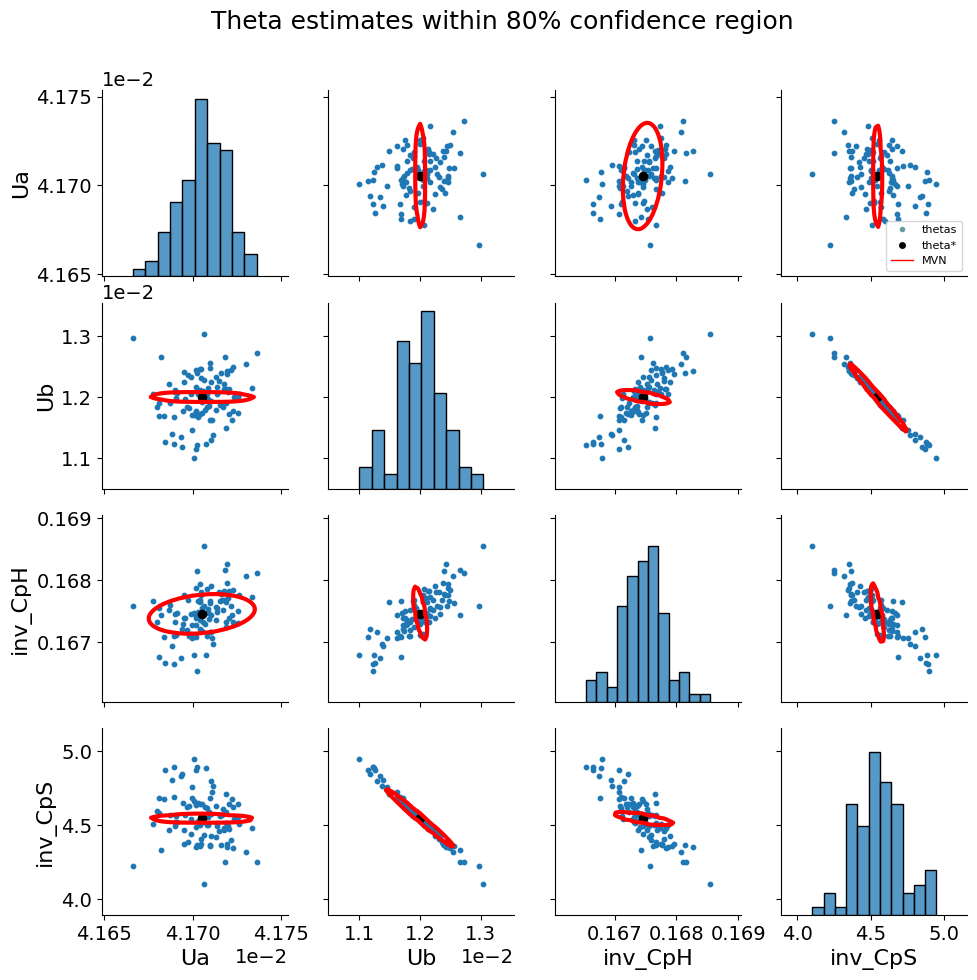

In [7]:
if parmest.graphics.seaborn_available:
    parmest.graphics.pairwise_plot(
        (theta_phys_est, cov_regL2_phys, 100),
        theta_star=theta_phys_est,
        alpha=0.8,
        distributions=['MVN'],
        title='Theta estimates within 80% confidence region',
    )

### Connection to MAP Estimation

Maximum a posteriori (MAP) estimation incorporates both the likelihood of the
data and a prior distribution over the parameters. The MAP estimate is defined
as

$$
   \hat{\boldsymbol{\theta}}_{\text{MAP}}
   =
   \arg\max_{\boldsymbol{\theta}}
   p(\boldsymbol{\theta} \mid \boldsymbol{x}, \boldsymbol{y})
$$

Using Bayes' rule,

$$
   p(\boldsymbol{\theta} \mid \boldsymbol{x}, \boldsymbol{y})
   \propto
   p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
   p(\boldsymbol{\theta})
$$

so that MAP estimation can be written as

$$
   \hat{\boldsymbol{\theta}}_{\text{MAP}}
   =
   \arg\min_{\boldsymbol{\theta}}
   \left[
      -
      \log p(\boldsymbol{y} \mid \boldsymbol{x}, \boldsymbol{\theta})
      -
      \log p(\boldsymbol{\theta})
   \right]
$$

The first term corresponds to the parameter estimation objective from the
current data. The second term corresponds to a regularization term induced by
the prior distribution.

For example, an $L_2$ regularization term corresponds to a Gaussian prior centered
at $\boldsymbol{\theta}_0$:

$$
   \boldsymbol{\theta}
   \sim
   \mathcal{N}
   \left(
      \boldsymbol{\theta}_0,
      \boldsymbol{F}_{\text{prior}}^{-1}
   \right)
$$

The negative log-prior is proportional to

$$
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)^\text{T}
   \boldsymbol{F}_{\text{prior}}
   \left(\boldsymbol{\theta} - \boldsymbol{\theta}_0\right)
$$

which is the $L_2$ regularization term.

## Activity: How does the strength of the prior affect the parameter estimation?

How does the strength of the physical prior affect the estimate covariance, and the Fisher information matrix of the system?

One goal of using regularization is to improve the conditioning of the covariance results. Another way to say this is regularization raises the minimum eigenvalue of the Fisher information matrix, improving the overall estimability.

In the cell below, the main control is a variable, prior_weight which is previously set to 2. How does adjusting the prior weight impact the results?

In [8]:
# Redefine the prior_FIM_phys with a scaling factor to demonstrate tuning regularization strength
prior_FIM_phys= pd.DataFrame(
    np.linalg.inv(cov_x.values),
    index=cov_x.index,
    columns=cov_x.columns,
)

# Helper to compute metrics from a covariance matrix (accepts pandas DataFrame or ndarray)
def cov_metrics(cov):
    cov_arr = cov.values if hasattr(cov, "values") else np.asarray(cov)
    FIM = np.linalg.inv(cov_arr)
    eigs = np.linalg.eigvals(FIM)
    return {
        "trace_cov": np.trace(cov_arr),
        "determinant_FIM": np.linalg.det(FIM),
        "min_eigenvalue_FIM": np.min(eigs).real,
        "condition_number_FIM": np.linalg.cond(FIM),
    }

# Ensure original covariance exists (from prior_weight=2 run)
cov_orig = cov_regL2_phys

metrics_orig = cov_metrics(cov_orig)

In [9]:
# Choose a new prior weight to demonstrate the effect of tuning regularization strength
prior_weight = 1
prior_FIM_activity = prior_weight * prior_FIM_phys

# Calculate the parameter estimates with the new scaled prior_FIM_phys to demonstrate tuning regularization strength
pest_activity = parmest.Estimator([TC_Lab_sine_exp, ], obj_function='SSE_weighted', 
                                  solver_options=solver_options, regularization='L2', 
                                  prior_FIM=prior_FIM_activity, theta_ref=theta0_phys)
obj_activity, theta_activity = pest_activity.theta_est()

# Calculate covariance of parameter estimates for regularized estimation with physical prior
cov_activity = pest_activity.cov_est()
metrics_current = cov_metrics(cov_activity)

# Assemble comparison table
orig_col = "prior_weight=2 (original)"
cur_col = f"prior_weight={prior_weight} (current)"
comparison = pd.DataFrame(
    {orig_col: metrics_orig, cur_col: metrics_current}
)

# display the table
comparison = comparison.T
comparison.round(6)

,trace_cov,determinant_FIM,min_eigenvalue_FIM,condition_number_FIM
prior_weight=2 (original),0.024999,6.053411e+27,40.001024,1.796418e+08
prior_weight=1 (current),0.049999,3.026707e+27,20.000512,3.592836e+08


### Takeaways from the activity

1. Increasing the strength of the prior reduces the uncertainty.
2. Use caution when doing this from physical intuition unless confident in the results.
3. This FIM activity is a simple example of what is done with design of experiments in Pyomo.DoE next session to pick experimental conditions.